# corso fisica computazionale

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from scipy.special import factorial as fact

## ERROR ANALYSIS

Consider the function $ f(x) = e^x $ for $ x \in [0,1] $. Write a program that computes the truncated series $ g_N(x) = \sum_{n=0}^{N} \frac{x^n}{n!}. $

(a) Verify that the absolute error $ \Delta = |f(x) - g_N(x)| $ scales approximately as $ \frac{x^{N+1}}{(N+1)!} $ for $ N = 1,2,3,4 $. 

(b) The error $ \Delta $ in $ [0,1] $ differs from $ \frac{x^{N+1}}{(N+1)!}. $ Why, and for which values of $ x $?

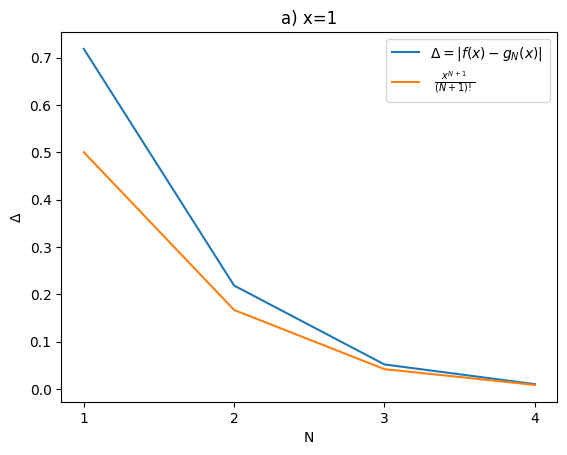

In [3]:
# Question a)
N = 100

def gN(x: np.ndarray | float,N: int) -> float:
    return np.sum([x**n / fact(n) for n in range(0,N+1)])

x = 1
Ns = np.arange(0,100)
y = np.array([gN(x,N) for N in Ns])

Ns = np.array([1,2,3,4])
Δ = np.abs(np.exp(x) - y[1:5])
teoΔ = x**(Ns+1)/fact(Ns+1)

plt.title(f'a) x={x}')
plt.plot(Ns,Δ,label='$ \\Delta = |f(x) - g_N(x)| $ ')
plt.plot(Ns,teoΔ,label=' $ \\frac{x^{N+1}}{(N+1)!} $')
plt.xlabel('N')
plt.ylabel('$\\Delta$')
plt.xticks(Ns)
plt.legend()
plt.show()

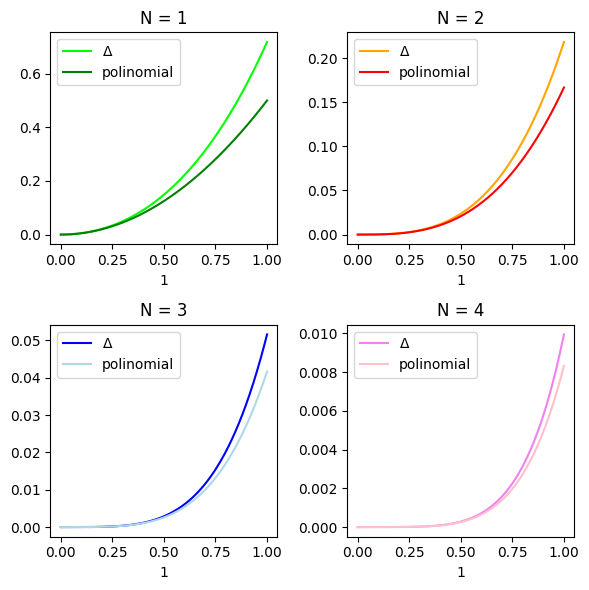

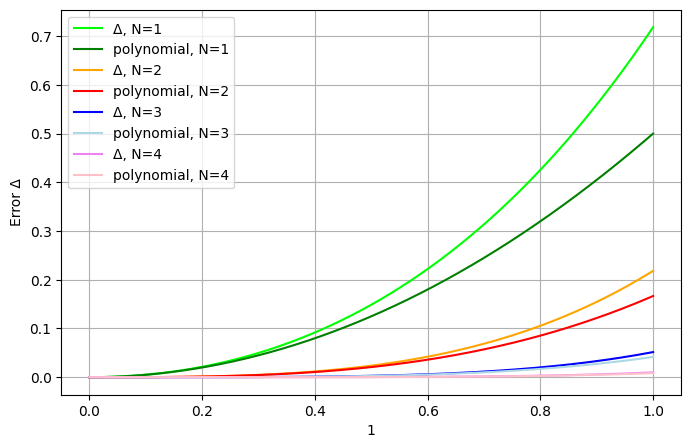

In [4]:
# Question b)

X = np.linspace(0,1,1000)
g1x = np.array([gN(x,1) for x in X])
g2x = np.array([gN(x,2) for x in X])
g3x = np.array([gN(x,3) for x in X])
g4x = np.array([gN(x,4) for x in X])

fx = np.exp(X)

Δ1 = np.abs(g1x - fx)
Δ2 = np.abs(g2x - fx)
Δ3 = np.abs(g3x - fx)
Δ4 = np.abs(g4x - fx)

teoΔ1 = X**2/fact(2)
teoΔ2 = X**3/fact(3)
teoΔ3 = X**4/fact(4)
teoΔ4 = X**5/fact(5)

fig, ((ax1,ax2),(ax3,ax4))= plt.subplots(2, 2, figsize=(6, 6))

ax1.set_title('N = 1')
ax1.plot(X, Δ1, label='$\\Delta$', color='lime')
ax1.plot(X, teoΔ1, label='polinomial', color='green')
ax1.set_xlabel(x)
ax1.legend()

ax2.set_title('N = 2')
ax2.plot(X, Δ2, label='$\\Delta$', color='orange')
ax2.plot(X, teoΔ2, label='polinomial', color='red')
ax2.set_xlabel(x)
ax2.legend()

ax3.set_title('N = 3')
ax3.plot(X, Δ3, label='$\\Delta$', color='blue')
ax3.plot(X, teoΔ3, label='polinomial', color='lightblue')
ax3.set_xlabel(x)
ax3.legend()

ax4.set_title('N = 4')
ax4.plot(X, Δ4, label='$\\Delta$', color='violet')
ax4.plot(X, teoΔ4, label='polinomial', color='pink')
ax4.set_xlabel(x)
ax4.legend()

plt.tight_layout()
plt.show()



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

# Plot N=1
ax.plot(X, Δ1, label='Δ, N=1', color='lime')
ax.plot(X, teoΔ1, label='polynomial, N=1', color='green')

# Plot N=2
ax.plot(X, Δ2, label='Δ, N=2', color='orange')
ax.plot(X, teoΔ2, label='polynomial, N=2', color='red')

# Plot N=3
ax.plot(X, Δ3, label='Δ, N=3', color='blue')
ax.plot(X, teoΔ3, label='polynomial, N=3', color='lightblue')

# Plot N=4
ax.plot(X, Δ4, label='Δ, N=4', color='violet')
ax.plot(X, teoΔ4, label='polynomial, N=4', color='pink')

# Labels, legend, grid
ax.set_xlabel(x)
ax.set_ylabel('Error Δ')
ax.legend()
ax.grid(True)

plt.show()

Calculate the sum

$$
\sum_{n=1}^{\infty} \frac{1}{n^2} = \frac{\pi^2}{6} = \lim_{N \to \infty} S(N), \quad
S(N) = \sum_{n=1}^{N} \frac{1}{n^2}.
$$

(a) Calculate the sum in **single precision** using **normal ordering**: (n = 1,2,3,...,N).  

(b) Calculate the sum in **single precision** using **reverse ordering**: (n = N, N-1, ..., 1).  

(c) Study the convergence of both implementations as a function of \(N\) by plotting 
$
\left| S(N) - \frac{\pi^2}{6} \right|.
$

(d) Repeat (a)-(c) using **double precision**.  

(e) Can you explain what happens?

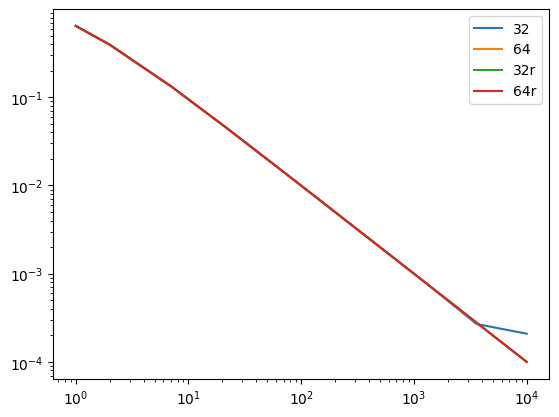

In [5]:
N = np.logspace(0, 4, 10, base=10).astype(int)

def Sn32(N):
    res = np.float32(0)
    for i in range(1,N+1):
        res += (1/(np.float32(i)**2))
    return res

def Sn64(N):
    res = np.float64(0)
    for i in range(1,N+1):
        res += (1/(np.float64(i)**2))
    return res

def Sn32_r(N):
    res = np.float32(0)
    for i in range(N,0,-1):
        res += (1/(np.float32(i)**2))
    return res

def Sn64_r(N):
    res = np.float64(0)
    for i in range(N,0,-1):
        res += (1/(np.float64(i)**2))
    return res

sn64 = np.array([Sn64(n) for n in N], dtype=np.float64)
sn32 = np.array([Sn32(n) for n in N], dtype=np.float32)
sn64r = np.array([Sn64_r(n) for n in N], dtype=np.float64)
sn32r = np.array([Sn32_r(n) for n in N], dtype=np.float32)

Δ32 = np.abs(sn32 - np.float32(np.pi**2/6))
Δ64 = np.abs(sn64 - np.float64(np.pi**2/6))
Δ32r = np.abs(sn32r - np.float32(np.pi**2/6))
Δ64r = np.abs(sn64r - np.float64(np.pi**2/6))

plt.plot(N,Δ32,label='32')
plt.plot(N,Δ64,label='64')
plt.plot(N,Δ32r,label='32r')
plt.plot(N,Δ64r,label='64r')

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.show()

The Chaotic Bank Society proposes the following saving plan:

- Initial deposit: 

$$
C_0 = e - 1, \quad e \approx 2.7182818
$$

- Year 1: multiply capital by 1 and subtract \$1 as banking charges.  
- Year 2: multiply capital by 2 and subtract \$1.  
- Year 3: multiply capital by 3 and subtract \$1.  
- … and so on: in the \(n\)-th year, multiply capital by \(n\) and subtract \$1.

---

(a) Write a program to compute the total savings after **25 years** starting from

$$
C_0 = e - 1 \approx 1.71828182845904523536028747135
$$

(b) Are you considering subscribing to this plan? Motivate your answer.

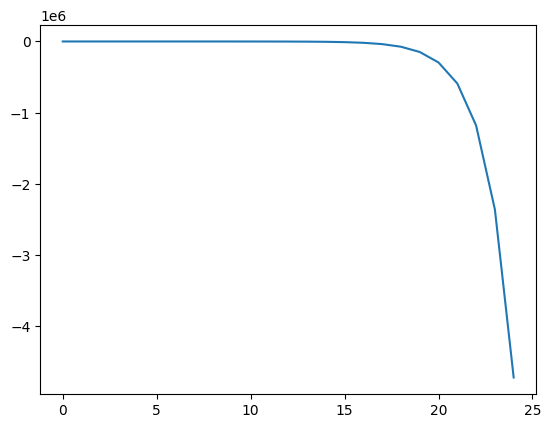

In [6]:
C0 = np.float64(1.71828182845904523536028747135)
year = 24

C = [C0]

for i in range(1,year+1):
    C.append(2*(C[i-1] - 1))

plt.plot(C)
plt.show()

## Varianza

1. (a) In statistics, the variance of a sample \(x_1, ..., x_n\) is defined as:

$$
\sigma^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2, 
\quad 
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i.
$$

- Write a function that takes a vector $(x)$ of any length and returns $(\sigma^2)$ using this formula.  
- Test your function with $(x = [1,1,...,1])$ and some random vectors.

---

(b) A drawback of the formula above is that it requires **two passes** through the data: one to compute \(\bar{x}\), and one to compute the sum of squared differences. For large datasets or streaming data, a **single-pass formula** is useful:

$$
\sigma^2 = \frac{1}{n-1} \left( u - \frac{v^2}{n} \right), 
\quad 
u = \sum_{i=1}^{n} x_i^2, \quad v = \sum_{i=1}^{n} x_i.
$$

- Try both formulas on the datasets below, each of which has an **exact variance equal to 1**.  
- Use both **single** and **double precision**.

$$
x = [10^3, 1+10^3, 2+10^3], \quad
x = [10^6, 1+10^6, 2+10^6], \quad
x = [10^7, 1+10^7, 2+10^7], \quad
x = [10^8, 1+10^8, 2+10^8]
$$

- Can you explain the results?


(c) (Optional) Instead of accumulating $(\sum_i x_i)$ and $(\sum_i x_i^2)$, we can accumulate

$$
M_k = \frac{1}{k} \sum_{i=1}^{k} x_i, \quad
Q_k = \sum_{i=1}^{k} (x_i - M_k)^2 = \sum_{i=1}^{k} x_i^2 - \frac{1}{k} \left(\sum_{i=1}^{k} x_i \right)^2
$$

via the **updating formulas**:

$$
M_1 = x_1, \quad M_k = M_{k-1} + \frac{x_k - M_{k-1}}{k}, \quad k=2,\dots,n,
$$

$$
Q_1 = 0, \quad Q_k = Q_{k-1} + \frac{k-1}{k} (x_k - M_{k-1})^2, \quad k=2,\dots,n,
$$

after which the variance is

$$
\sigma^2 = \frac{Q_n}{n-1}.
$$

In [7]:
def var_recursive(x):
    n = len(x)
    M1 = x[0]
    Q1 = 0
    for k in range(1,n):
        Mk = M1 + ((x[k] - M1)/k)
        Qk = Q1 + (k-1)*((x[k] - M1)**2)/k
        M1 = Mk
        Q1 = Qk
    return Qk/(n-1)

In [8]:
# x = np.random.random(100000)
# x = np.array(x,dtype=np.float32)
# y = np.array(x,dtype=np.float64)

dataset = [
    [ 1e3, 1+1e3, 2+1e3 ],
    [ 1e6, 1+1e6, 2+1e6 ],
    [ 1e7, 1+1e7, 2+1e7 ],
    [ 1e8, 1+1e8, 2+1e8 ],
]

def var_one_loop(x):
    n = len(x)
    u,v = 0,0
    for i in x: # loop
        u += i**2
        v += i
    return 1/(n-1) * (u - v**2/n)

def var_two_loop(x):
    n = len(x)
    mean = np.sum(x)/n # loop
    return 1/(n-1) * np.sum((x - mean)**2) # loop

def var_recursive(x):
    n = len(x)
    M1 = x[0]
    Q1 = 0
    for k in range(1,n):
        Mk = M1 + ((x[k] - M1)/k)
        Qk = Q1 + (k-1)*((x[k] - M1)**2)/k
        M1 = Mk
        Q1 = Qk
    return Qk/(n-1)

for i in range(0,len(dataset)):
    x = np.array(dataset[i], dtype=np.float32)
    y = np.array(dataset[i], dtype=np.float64)
    σ2321 = var_one_loop(x)
    σ2322 = var_two_loop(x)
    σ232r = var_recursive(x)
    σ2641 = var_one_loop(y)
    σ2642 = var_two_loop(y)
    σ264r = var_recursive(y)

    print(f'-----------dataset {i} --------------')
    print(σ2321, σ2322, σ232r, sep='\n')
    print(σ2641, σ2642, σ264r, sep='\n')




-----------dataset 0 --------------
1.0
1.0
0.25
1.0
1.0
0.25
-----------dataset 1 --------------
-131072.0
1.0
0.25
1.0
1.0
0.25
-----------dataset 2 --------------
0.0
1.0
0.25
1.0
1.0
0.25
-----------dataset 3 --------------
0.0
0.0
0.0
0.0
1.0
0.25


## LINEAR SYSTEMS

# Forward Substitution

## Task
Write a function that solves $( Lx = b )$ using **forward substitution**, where:
- $( L \in \mathbb{R}^{n \times n} )$ is lower triangular
- $( b \in \mathbb{R}^n )$

The function should return the solution vector $( x )$.

## Verification
Check your result by confirming $( Lx - b = 0 )$.

In [ ]:
A = [
    [4, 0, 0, 0],
    [1, -2, 0, 0],
    [-1, 4, 4, 0],
    [2, -5, 5, 1]
]

b = [-4, 1, -3, 5]

def forward_substitution(A,b):
    n = len(A)
    x = []
    x.append(b[0]/A[0][0])
    for i in range(1,n):
        x.append((b[i] -  np.sum([A[i][k]*x[k] for k in range(0,i)]))/A[i][i])
    return x

def vec_dot(A,x):
    n = len(A)
    res = []
    for i in range(n):
        line = 0
        for j in range(n):
            line += A[i][j]*x[j]
        res.append(line)
    return res

def vec_diff(a,b):
    n = len(a)
    return [i-j for i,j in zip(a,b)]

def vec_sum(a,b):
    return [i+j for i,j in zip(a,b)]

print('forward')
x = forward_substitution(A,b)
print('solution: ', x)
print(vec_diff(vec_dot(A,x),(b))) # proof

def backward_substitution(A,b):
    n = len(A)
    x = [None for _ in range(n)]
    x[-1] = b[-1]/A[-1][-1]
    for i in range(-2,-n-1,-1):
        x[i] = ((b[i] - np.sum([A[i][k]*x[k] for k in range(i+1,0)]))/A[i][i])
    return x

print("")
print('backward')
A = [
    [3, 1, 0, 6],
    [0, -1, -2, 7],
    [0, 0, 3, 4],
    [0, 0, 0, 5]
]

b = [4, 1, 1, 5]

x = backward_substitution(A,b)
print('solution: ', x)
print(vec_diff(vec_dot(A,x),b))

forward
solution:  [-1.0, np.float64(-1.0), np.float64(0.0), np.float64(2.0)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]

backward
solution:  [np.float64(-3.3333333333333335), np.float64(8.0), np.float64(-1.0), 1.0]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


## (Optional) Multiple Right-Hand Sides and Matrix Inverse

Let $( B \in \mathbb{R}^{n \times p} )$ have columns $( b_1, \dots, b_p )$.  
We can solve $( p )$ linear systems at once by writing

$
AX = B,
$

where $( X \in \mathbb{R}^{n \times p} )$.

This implies that

$
A x_j = b_j, \quad \text{for } j = 1, \dots, p.
$

---

### (a) Multiple Right-Hand Sides

Modify your forward and backward substitution routines so that they handle the case where the second input is an $( n \times p )$ matrix with $( p \ge 1 )$, instead of a single vector.

---

### (b) Inverse of a Lower Triangular Matrix

If

$
AX = I,
$

then

$
X = A^{-1}.
$

Use this fact to write a function that computes the inverse of a **lower triangular matrix**.

Test your function on at least two nontrivial matrices.

> *Note:* This is just an exercise — computing matrix inverses explicitly is rarely recommended in numerical practice.

In [69]:
# multiple matrices p:

def multiple_forward_substitution(A,B):
    # A = n*n*p, b = n*p
    x=[]
    for a,b in zip(A,B):
        x.append(forward_substitution(a,b))
    return x

def multiple_backward_substitution(A,B):
    x = []
    for a,b in zip(A,B):
        x.append(backward_substitution(a,b))
    return x


def mat_mul(A,B):
    n = len(A)
    x=[[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                x[i][j] += A[i][k]*B[k][j]
    return x
            
# inverse

def gen_identity(n):
    return [[1 if j==i else 0 for j in range(n)] for i in range(n)]

def forward_inverse(A):
    n = len(A)
    A = [A for _ in range(n)]
    I = gen_identity(n)
    x = multiple_forward_substitution(A,I)
    # to the transpose
    return [[x[j][i] for j in range(n)] for i in range(n)]

A = [
    [-2, 0, 0],
    [1, -1, 0],
    [3, 2, 1]
]
y = forward_inverse(A)
print(mat_mul(A,y))

# reverse inverse
def backward_inverse(A):
    n = len(A)
    A = [A for _ in range(n)]
    I = gen_identity(n)
    x = multiple_backward_substitution(A,I)
    # to the transpose
    return [[x[j][i] for j in range(n)] for i in range(n)]

A = [
    [1, 0, 0],
    [0, -1, -2],
    [0, 0, 3]
]

y = backward_inverse(A)
print(mat_mul(A,y))


[[np.float64(1.0), np.float64(0.0), np.float64(0.0)], [np.float64(0.0), np.float64(1.0), np.float64(0.0)], [np.float64(0.0), np.float64(0.0), np.float64(1.0)]]
[[np.float64(1.0), np.float64(0.0), np.float64(0.0)], [np.float64(0.0), np.float64(1.0), np.float64(0.0)], [np.float64(0.0), np.float64(0.0), np.float64(1.0)]]
